# Import libraries

In [37]:
import numpy as np 
import pandas as pd 
import os
import missingno as msno
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import RobustScaler

# import data

In [38]:
def read_data(path):
    files = os.listdir(path)
    grouped = {}
    for f in files:
        if not f.endswith('.png'):
            prefix = f.split('_')[0]
            grouped.setdefault(prefix, []).append(f)
            grouped[prefix].sort()
    
    pairs = [filenames for filenames in grouped.values() if len(filenames) == 2]

    dfs = []
    for p1, p2 in pairs: 
        prefix = p1.split('_')[0]
        temp_df = pd.DataFrame({})
        temp_df['id'] = prefix
        df1 = pd.read_csv(path+p1)
        df2 = pd.read_csv(path+p2)
        df1 = df1.rename(columns = {'GR': 'GR_h'})
        df2 = df2.rename(columns = {'GR': 'GR_v', 'TVT': 'TVT_v'})
        df1 = df1.sort_values(by = 'TVT_input')
        df1 = df1.dropna(subset = ['TVT_input'])
       
        temp_df = pd.merge_asof(df1, df2, left_on = 'TVT_input', right_on = 'TVT_v',direction = 'nearest')
        temp_df.insert(0, 'id', prefix)
        dfs.append(temp_df)

    result_df = pd.concat(dfs, ignore_index = True)
    return result_df

In [39]:
path_train = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/'
path_test = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/'

train_df = read_data(path_train)
test_df = read_data(path_test)

In [40]:
train_df

,id,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR_h,TVT_input,TVT_v,GR_v,Geology
0,75d20a82,11394.00,2923616.01,1016054.69,-9299.47,-9808.28,-10034.85,-10073.75,-10149.14,-10195.99,-10355.21,11065.12,126.46,11065.12,11064.95,128.98,OLMOS
1,75d20a82,11395.00,2923616.00,1016054.68,-9300.47,-9808.24,-10034.81,-10073.71,-10149.10,-10195.95,-10355.17,11066.16,NaN,11066.16,11065.95,131.85,OLMOS
2,75d20a82,11396.00,2923615.98,1016054.68,-9301.47,-9808.20,-10034.77,-10073.67,-10149.06,-10195.91,-10355.14,11067.20,133.59,11067.20,11066.95,133.30,OLMOS
3,75d20a82,11397.00,2923615.97,1016054.67,-9302.47,-9808.16,-10034.73,-10073.63,-10149.02,-10195.87,-10355.10,11068.24,136.48,11068.24,11068.45,130.29,OLMOS
4,75d20a82,11398.00,2923615.96,1016054.67,-9303.47,-9808.13,-10034.70,-10073.60,-10148.99,-10195.83,-10355.06,11069.28,NaN,11069.28,11069.45,130.98,OLMOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308261,99529c45,11982.00,2897708.13,1023913.60,-9163.40,-8724.12,-8959.16,-9018.40,-9052.99,-9073.34,-9208.19,11162.54,98.60,11162.54,11162.45,96.52,EGFDL
1308262,99529c45,11978.00,2897710.68,1023910.51,-9163.50,-8724.23,-8959.26,-9018.51,-9053.09,-9073.45,-9208.29,11162.54,NaN,11162.54,11162.45,96.52,EGFDL
1308263,99529c45,11979.00,2897710.04,1023911.28,-9163.48,-8724.19,-8959.23,-9018.48,-9053.06,-9073.41,-9208.26,11162.54,93.21,11162.54,11162.45,96.52,EGFDL
1308264,99529c45,11980.00,2897709.40,1023912.05,-9163.45,-8724.16,-8959.20,-9018.44,-9053.03,-9073.38,-9208.23,11162.55,94.98,11162.55,11162.45,96.52,EGFDL


In [41]:
train_df.isnull().sum()

id                0
MD                0
X                 0
Y                 0
Z                 0
ANCC          12930
ASTNU             0
ASTNL             0
EGFDU             0
EGFDL          1748
BUDA              0
TVT               0
GR_h         307135
TVT_input         0
TVT_v             0
GR_v              0
Geology      224301
dtype: int64

In [42]:
test_df.isnull().sum()

id             0
MD             0
X              0
Y              0
Z              0
GR_h         718
TVT_input      0
TVT_v          0
GR_v           0
dtype: int64

In [43]:
test_df.shape

(5070, 9)

In [44]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
train_df[['GR_v', 'GR_h']].describe()

,GR_v,GR_h
count,1308266.00,1001131.00
mean,89.52,88.25
std,27.60,27.30
min,25.27,20.39
25%,71.29,69.57
50%,87.79,85.99
75%,105.81,104.28
max,433.58,362.70


<Axes: xlabel='Column', ylabel='Value'>

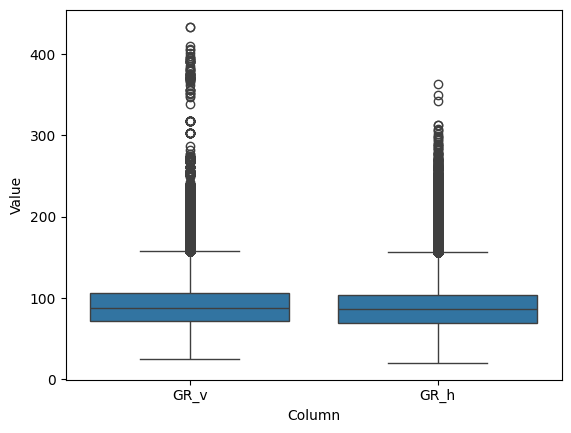

In [45]:
grs = train_df[['GR_v', 'GR_h']].melt(var_name='Column', value_name='Value')
sns.boxplot(grs, x='Column', y = 'Value')

In [46]:
train_df[['X', 'Y', 'Z']].describe()

,X,Y,Z
count,1308266.00,1308266.00,1308266.00
mean,2967537.83,1075336.05,-9283.63
std,46738.40,35326.51,654.97
min,2858892.37,1007175.50,-10841.23
25%,2921677.28,1041347.90,-9797.05
50%,2986783.91,1082701.82,-9164.50
75%,3007407.38,1104753.30,-8809.02
max,3037463.83,1138105.78,-7174.22


In [47]:
test_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v'], dtype='object')

In [48]:
train_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL',
       'BUDA', 'TVT', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v', 'Geology'],
      dtype='object')

# data processing

In [49]:
def data_processing(df): 
    df = df.sort_values(by = ['id', 'MD']).reset_index()
    df = df.drop(['TVT_input', 'TVT_v'], axis = 1)
    if 'ANCC' in df.columns: 
        df = df.drop(['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL','BUDA','Geology'], axis = 1)
    # get angle of that well for different MD
    window = 3
    df[['dMD', 'dZ']] = df.groupby('id')[['MD', 'Z']].diff(periods=window)
    df['theta'] = (df['dZ']/df['dMD']).abs()
    df['theta'] = df['theta'].ffill().bfill()
    df[['dMD', 'dZ']] =  df[['dMD', 'dZ']].bfill()
    df = df.drop(['dMD'], axis = 1)
    df['GR_v_rmean'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['GR_v_rstd'] =  df.groupby('id')['GR_v'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['GR_h_rmean'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).mean().reset_index(level=0, drop=True)
    df['GR_h_rstd'] =  df.groupby('id')['GR_h'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['GR_h'] = df['GR_h'].fillna(-999)
    df['X_rmean'] = df.groupby('id')['X'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)
    df['Y_rmean'] = df.groupby('id')['Y'].rolling(window=3, min_periods=1).std().reset_index(level=0, drop=True)

    scaler = RobustScaler()
    num_cols = df.select_dtypes(include='number').columns.tolist()
    df[num_cols] = scaler.fit_transform(df[num_cols])
    return df

In [50]:
train_df_p = data_processing(train_df.copy())
test_df_p = data_processing(test_df.copy())

<Axes: >

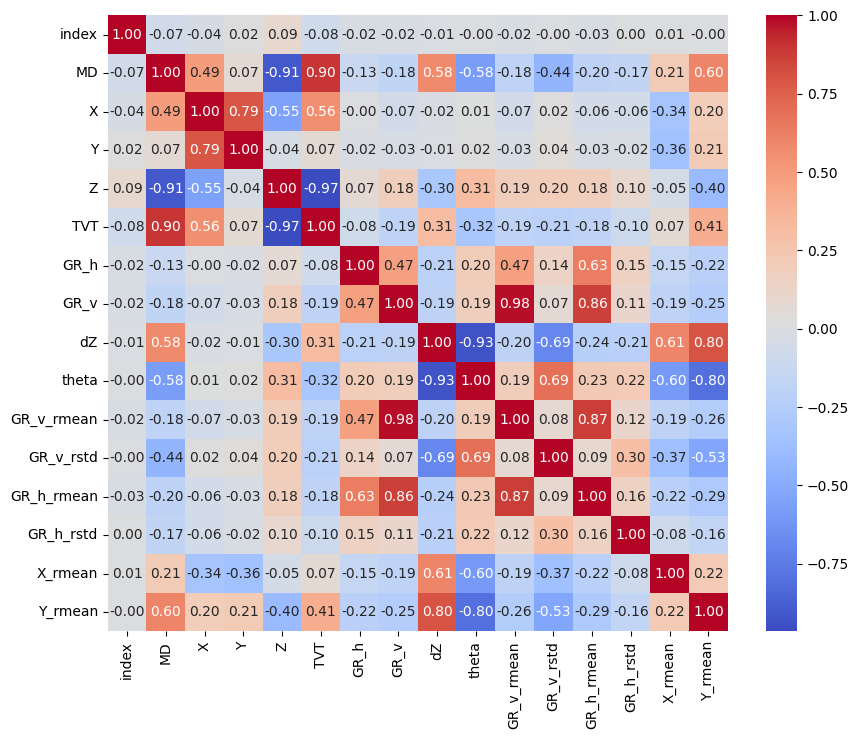

In [51]:
corr_mat = train_df_p.drop('id', axis = 1).corr(method = 'spearman')
plt.figure(figsize = (10,8))
sns.heatmap(corr_mat, cmap = 'coolwarm', annot=True, fmt = '.2f')